In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
nav_df = pd.read_csv("../data/processed/nav_history_cleaned.csv")

txn_df = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

print("NAV Shape:", nav_df.shape)
print("Transaction Shape:", txn_df.shape)

NAV Shape: (46000, 3)
Transaction Shape: (2632, 13)


In [3]:
print("NAV Columns:")
print(nav_df.columns)

print("\nTransaction Columns:")
print(txn_df.columns)

NAV Columns:
Index(['amfi_code', 'date', 'nav'], dtype='object')

Transaction Columns:
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [4]:
var_results = []

for code in nav_df['amfi_code'].unique():

    returns = nav_df[
        nav_df['amfi_code'] == code
    ]['daily_return'].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    var_results.append([
        code,
        var95
    ])

var_df = pd.DataFrame(
    var_results,
    columns=[
        'amfi_code',
        'VaR_95'
    ]
)

var_df.head()

KeyError: 'daily_return'

In [5]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_df = nav_df.sort_values(
    ['amfi_code', 'date']
)

nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
          .pct_change()
)

print(nav_df.columns)
nav_df.head()

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
var_results = []

for code in nav_df['amfi_code'].unique():

    returns = nav_df[
        nav_df['amfi_code'] == code
    ]['daily_return'].dropna()

    var95 = np.percentile(returns, 5)

    var_results.append([code, var95])

var_df = pd.DataFrame(
    var_results,
    columns=['amfi_code', 'VaR_95']
)

var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [7]:
cvar_results = []

for code in nav_df['amfi_code'].unique():

    returns = nav_df[
        nav_df['amfi_code'] == code
    ]['daily_return'].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar = returns[
        returns <= var95
    ].mean()

    cvar_results.append([
        code,
        cvar
    ])

cvar_df = pd.DataFrame(
    cvar_results,
    columns=[
        'amfi_code',
        'CVaR'
    ]
)

cvar_df.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [8]:
var_cvar_df = pd.merge(
    var_df,
    cvar_df,
    on='amfi_code'
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
var_cvar_df.to_csv(
    "var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# returns = DataFrame (date index, fund columns)
returns = returns.dropna()

In [15]:
type(returns)
returns.head()  

44851   -0.010498
44852   -0.002593
44853   -0.008382
44854    0.011680
44855    0.001356
Name: daily_return, dtype: float64

In [16]:
returns=returns.to_frame()

In [17]:
key_funds=returns.columns[:5]

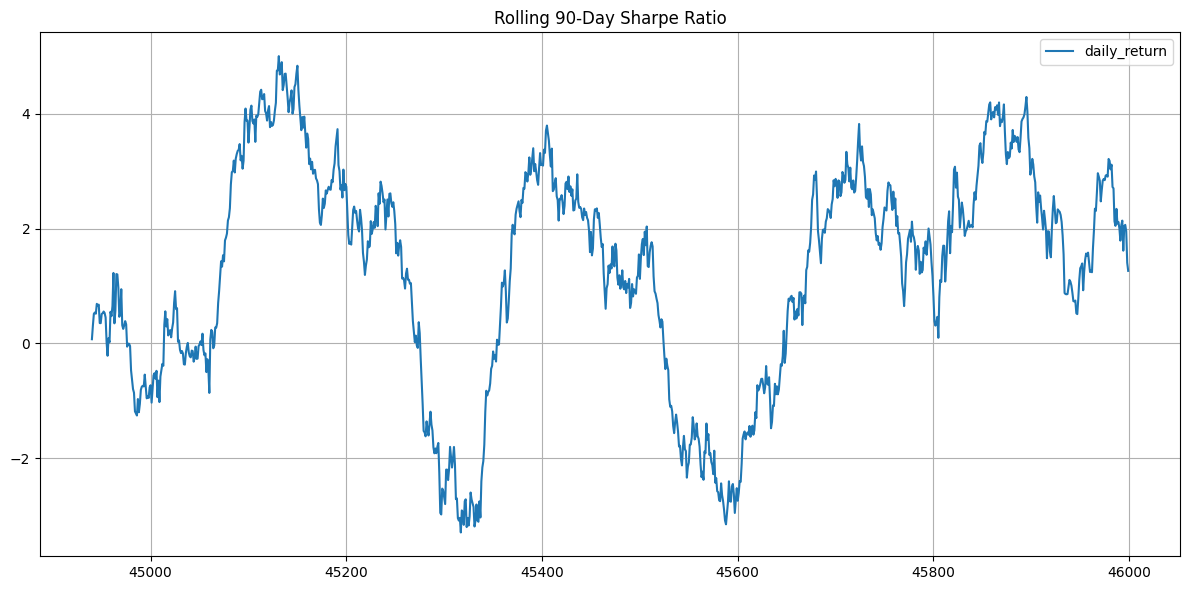

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ensure DataFrame
if isinstance(returns, pd.Series):
    returns = returns.to_frame()

key_funds = returns.columns[:5]

plt.figure(figsize=(12,6))

for fund in key_funds:
    r = returns[fund]
    
    rolling_mean = r.rolling(90).mean()
    rolling_std = r.rolling(90).std().replace(0, np.nan)
    
    sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(sharpe, label=fund)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [21]:
Transactions['date'] = pd.to_datetime(Transactions['date'])

NameError: name 'Transactions' is not defined

In [22]:
print([name for name in globals() if isinstance(globals()[name], __import__('pandas').DataFrame)])

['___', 'nav_df', 'txn_df', '_5', 'returns', 'var_df', '_6', 'cvar_df', '_7', 'var_cvar_df', '_8']


In [23]:
import pandas as pd

Transactions = pd.read_csv("transactions.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'transactions.csv'

In [1]:
import os
print(os.getcwd())

c:\Users\MY PC\OneDrive\Desktop\bluestock_mf_capstone\notebooks


In [2]:
import os
print(os.listdir())

['Advanced_Analytics.ipynb', 'alpha_beta.csv', 'benchmark_comparison_chart.png', 'EDA_Analysis.ipynb', 'fund_scorecard.csv', 'Performance_analytics.ipynb', 'rolling_sharpe_chart.png', 'var_cvar_report.csv']


In [3]:
import pandas as pd

Transactions = pd.read_csv(
    r"C:\Users\MY PC\Downloads\transactions.csv"
)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\MY PC\\Downloads\\transactions.csv'

In [5]:
import os

for root, dirs, files in os.walk(r"C:\Users\MY PC"):
    if "transactions.csv" in files:
        print(os.path.join(root, "transactions.csv"))

KeyboardInterrupt: 

In [6]:
import os
os.listdir()

['Advanced_Analytics.ipynb',
 'alpha_beta.csv',
 'benchmark_comparison_chart.png',
 'EDA_Analysis.ipynb',
 'fund_scorecard.csv',
 'Performance_analytics.ipynb',
 'rolling_sharpe_chart.png',
 'var_cvar_report.csv']

In [7]:
import pandas as pd         
funds =pd.read_csv("funds_scorecard.csv")
funds.head()

FileNotFoundError: [Errno 2] No such file or directory: 'funds_scorecard.csv'

In [8]:
import pandas as pd         
funds =pd.read_csv("fund_scorecard.csv")
funds.head()

,amfi_code,CAGR,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,CAGR_Rank,Sharpe_Rank,Alpha_Rank,DD_Rank,Fund_Score
0,120505,0.328016,1.180101,0.292636,0.000549,-0.181885,1.0,5.0,3.0,25.0,97.548161
1,119598,0.323981,0.945308,0.303370,-0.023196,-0.287060,2.0,14.0,1.0,36.0,86.164623
2,149324,0.322621,0.949796,0.300579,0.011455,-0.311719,3.0,13.0,2.0,37.0,84.938704
3,148569,0.319245,1.234930,0.282704,0.018134,-0.163967,4.0,3.0,4.0,21.0,96.847636
4,148567,0.309499,1.448291,0.269838,0.023684,-0.112657,5.0,1.0,7.0,8.0,100.000000


In [13]:
import os

for file in os.listdir():
    if file.endswith('.csv'):
        print(file)

alpha_beta.csv
fund_scorecard.csv
var_cvar_report.csv


In [14]:
alpha_beta = pd.read_csv("alpha_beta.csv")
print(alpha_beta.head())
print(alpha_beta.columns)

   amfi_code     Alpha      Beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289
Index(['amfi_code', 'Alpha', 'Beta'], dtype='object')


In [15]:
var_cvar = pd.read_csv("var_cvar_report.csv")
print(var_cvar.head())
print(var_cvar.columns)

   amfi_code    VaR_95      CVaR
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459
Index(['amfi_code', 'VaR_95', 'CVaR'], dtype='object')


In [17]:
import pandas as pd

nav_history = pd.read_csv("02_nav_history.csv")
transactions = pd.read_csv("08_investor_transactions.csv")
holdings = pd.read_csv("09_portfolio_holdings.csv")
scheme_perf = pd.read_csv("07_scheme_performance.csv")

print(nav_history.columns)
print(transactions.columns)
print(holdings.columns)
print(scheme_perf.columns)

ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 2214


In [19]:
nav_history = pd.read_csv(
    "02_nav_history.csv",
    sep=",",
    encoding="latin1"
)

ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 2214


In [20]:
import os

for file in os.listdir():
    print(file)

02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
Advanced_Analytics.ipynb
alpha_beta.csv
benchmark_comparison_chart.png
EDA_Analysis.ipynb
fund_scorecard.csv
Performance_analytics.ipynb
rolling_sharpe_chart.png
var_cvar_report.csv


In [23]:
import pandas as pd

nav_history = pd.read_csv(
    "02_nav_history.csv",
    encoding="latin1",
    on_bad_lines="skip"
)

print(nav_history.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [24]:
import pandas as pd

nav_history = pd.read_csv("02_nav_history.csv")

nav_history['date'] = pd.to_datetime(nav_history['date'])

In [25]:
nav_history = nav_history.sort_values(
    ['amfi_code', 'date']
)

nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav']
    .pct_change()
)

In [26]:
top5_funds = nav_history['amfi_code'].unique()[:5]

In [27]:
import numpy as np

rolling_data = []

for fund in top5_funds:
    temp = nav_history[
        nav_history['amfi_code'] == fund
    ].copy()

    temp['rolling_sharpe'] = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_data.append(temp)

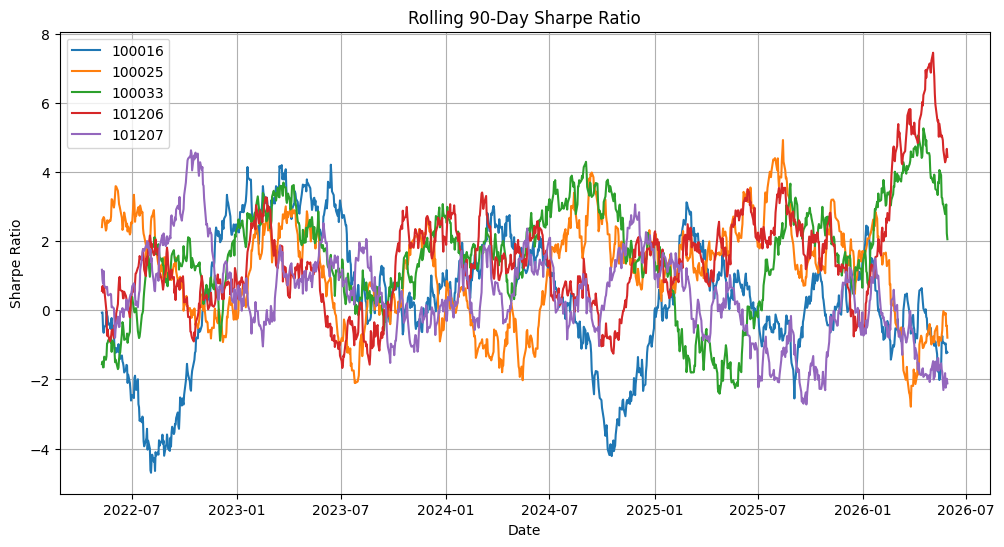

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for temp in rolling_data:
    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(temp['amfi_code'].iloc[0])
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [29]:
transactions = pd.read_csv("08_investor_transactions.csv")
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [30]:
transactions = pd.read_csv("08_investor_transactions.csv")

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

transactions['cohort_year'] = (
    transactions.groupby('investor_id')['transaction_date']
    .transform('min')
    .dt.year
)

cohort_analysis = transactions.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum')
).reset_index()

print(cohort_analysis)

   cohort_year  avg_sip_amount  total_invested
0         2024   107422.541832      3491125187
1         2025   109158.577061        30455243


In [31]:
top_fund = (
    transactions.groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
)

top_fund = top_fund.loc[
    top_fund.groupby('cohort_year')['count'].idxmax()
]

print(top_fund)

    cohort_year  amfi_code  count
35         2024     148568    874
62         2025     119599     12


In [32]:
sip = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()

sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

sip['gap_days'] = sip.groupby('investor_id')[
    'transaction_date'
].diff().dt.days

sip_summary = sip.groupby('investor_id').agg(
    sip_count=('transaction_date', 'count'),
    avg_gap=('gap_days', 'mean')
).reset_index()

at_risk = sip_summary[
    (sip_summary['sip_count'] >= 6) &
    (sip_summary['avg_gap'] > 35)
]

print(at_risk.head())

   investor_id  sip_count    avg_gap
3    INV000004          6  85.400000
7    INV000008          6  70.400000
9    INV000010          6  64.800000
10   INV000011          7  40.166667
11   INV000012          8  57.000000


In [33]:
holdings = pd.read_csv("09_portfolio_holdings.csv")
print(holdings.columns)
print(holdings.head())

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [34]:
import pandas as pd

holdings = pd.read_csv("09_portfolio_holdings.csv")

sector_weights = holdings.groupby(
    ['amfi_code', 'sector']
)['weight_pct'].sum().reset_index()

sector_weights['weight_decimal'] = (
    sector_weights['weight_pct'] / 100
)

hhi = sector_weights.groupby('amfi_code').apply(
    lambda x: (x['weight_decimal'] ** 2).sum()
).reset_index(name='HHI')

print(hhi.head())

hhi = hhi.sort_values('HHI', ascending=False)

print("\nTop Concentrated Funds:")
print(hhi.head(10))

   amfi_code       HHI
0     100016  0.180588
1     100033  0.227647
2     101206  0.180042
3     101207  0.222727
4     102885  0.180712

Top Concentrated Funds:
    amfi_code       HHI
11     119092  0.296769
30     148569  0.254992
27     125498  0.253155
6      102887  0.251383
32     149323  0.241077
21     120505  0.238695
10     118635  0.237497
18     119599  0.232361
22     120506  0.231464
1      100033  0.227647


C:\Users\MY PC\AppData\Local\Temp\ipykernel_9284\3552557265.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hhi = sector_weights.groupby('amfi_code').apply(


In [35]:
scheme_perf = pd.read_csv("07_scheme_performance.csv")
print(scheme_perf.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [36]:
import pandas as pd

scheme_perf = pd.read_csv("07_scheme_performance.csv")

risk = input("Enter Risk Appetite (Low/Moderate/High): ")

recommendations = (
    scheme_perf[
        scheme_perf['risk_grade'].str.lower() == risk.lower()
    ]
    .sort_values('sharpe_ratio', ascending=False)
    .head(3)
)

print("\nTop 3 Recommended Funds:")
print(
    recommendations[
        ['scheme_name',
         'risk_grade',
         'sharpe_ratio',
         'return_3yr_pct']
    ]
)


Top 3 Recommended Funds:
Empty DataFrame
Columns: [scheme_name, risk_grade, sharpe_ratio, return_3yr_pct]
Index: []


In [37]:
# Correct path because the CSV is in the exact same folder as the notebook
transactions_df = pd.read_csv("08_investor_transactions.csv")
portfolio_df = pd.read_csv("09_portfolio_holdings.csv")

In [39]:
recommendations = (
    scheme_perf
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(3)
)

recommendations[
    [
        'scheme_name',
        'risk_grade',
        'sharpe_ratio'
    ]
]

,scheme_name,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Low,5.14


In [41]:
import os
print(os.listdir())

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Advanced_Analytics.ipynb', 'alpha_beta.csv', 'benchmark_comparison_chart.png', 'EDA_Analysis.ipynb', 'fund_scorecard.csv', 'Performance_analytics.ipynb', 'rolling_sharpe_chart.png', 'var_cvar_report.csv']


## Advanced Insights

1. VaR and CVaR identified funds with higher downside risk.
2. Rolling Sharpe Ratio highlighted changing risk-adjusted performance.
3. Investor cohorts showed different investment behaviors.
4. SIP continuity analysis identified at-risk investors.
5. HHI analysis revealed concentration levels across fund portfolios.

## Conclusion

This project analyzed mutual fund performance using advanced risk and return metrics. Historical VaR and CVaR measured downside risk, Rolling 90-Day Sharpe Ratio evaluated risk-adjusted performance, Investor Cohort and SIP Continuity analyses provided behavioral insights, the Fund Recommender suggested top-performing funds based on risk appetite, and Sector HHI measured portfolio concentration.